# Subtyping EM with Grid Search and K-Fold Cross-Validation

This notebook performs grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.subtyping_em_transformer import SubtypingEM
from EMDPM.posthoc_burnin_subtype_initialization import initialize_subtypes_with_burnin

np.set_printoptions(precision=4)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# data params
n_biomarkers = 3
t_max = 12
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.1
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 3 #3,4,5
rng = np.random.RandomState(75)


For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.


SUBTYPE 0:
f: [0.  0.  0.3]
a = 4.676436127196727, b = 6.421955999238555


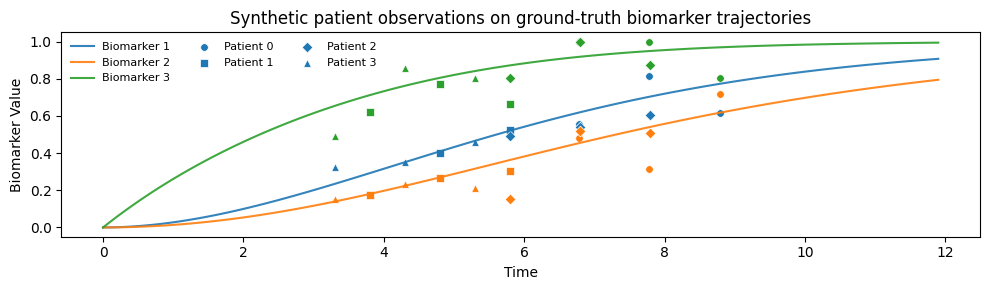

4.652100779497804
SUBTYPE 1:
f: [0.3 0.  0. ]
a = 1.1927249100009507, b = 6.8096301386771785


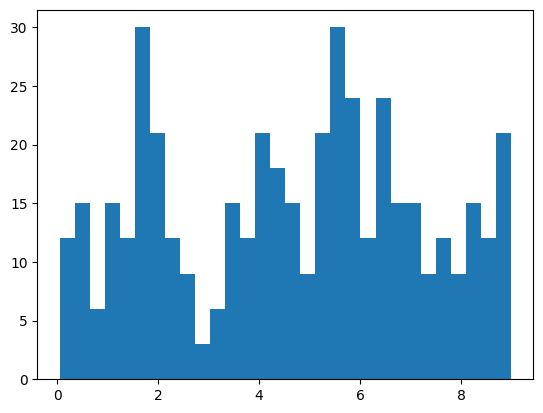

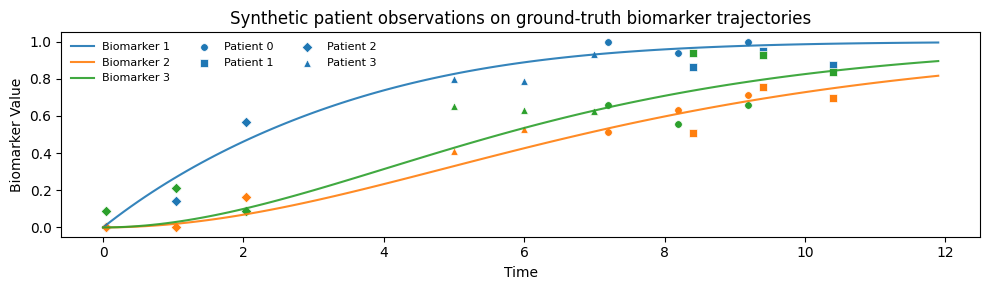

4.369259360008201
SUBTYPE 2:
f: [0.  0.3 0. ]
a = 3.0026725053615246, b = 4.680674259481151


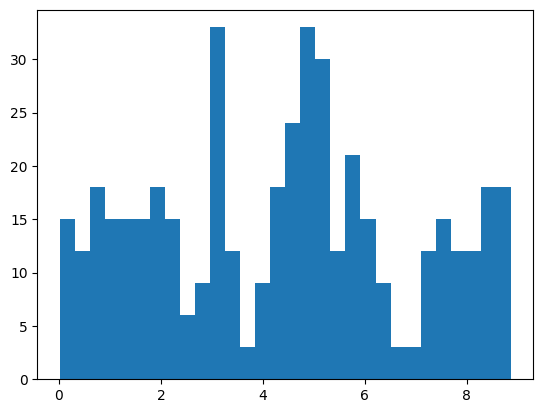

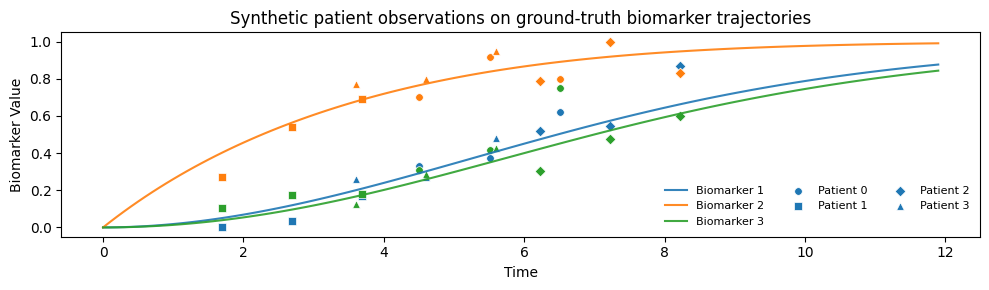

4.495167591409237


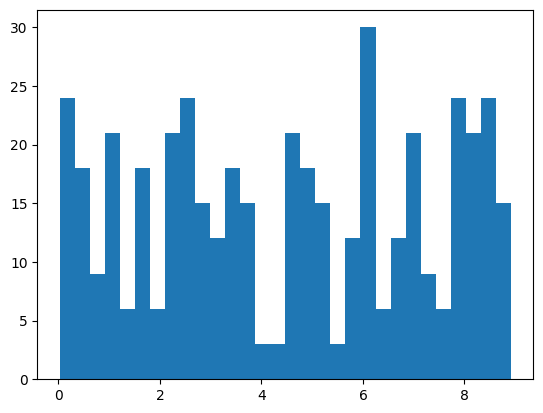

In [6]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.2, 0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.3, 0.0, 0.0]), np.array([0.0, 0.3, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype + 2),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    plt.hist(beta_true, bins=30)
    print(np.mean(beta_true))
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    
X = np.asarray(X)
y = np.concatenate(y)


In [7]:
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


beta_init summary: count    450.000000
mean       5.658365
std        3.471090
min        0.000000
25%        2.883176
50%        4.492429
75%        8.459931
max       12.000000
dtype: float64
Initialized beta for 450 patients
Beta range: [0.00, 12.00]
True beta range: [0.02, 8.99]


## Grid Search with K-Fold Cross-Validation

We'll perform grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [8]:
# Initialize f for all models
f_init = initialize_f_eigen(K=K)
if isinstance(f_init, list):
    f_init = f_init[0]

# Add initial_beta to patient data
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]
    # SubjectEM also expects beta_pred (use initial_beta as starting point)
    p["beta_pred"] = float(initial_beta[id_to_beta_idx[p["id"]]])

# Add initialization fields required by SubjectEM (for burn-in initialization)
# These are used as starting points for the per-patient SubjectEM burn-in
s_init = np.ones(n_biomarkers)  # Default initialization for s
scalar_K_init = float(np.max([np.max(p["X_obs"]) for p in X]))  # Use max observed value

for p in X:
    p["f_init"] = f_init.copy()  # Use the f_init from eigen initialization
    p["s_init"] = s_init.copy()
    p["scalar_K_init"] = scalar_K_init


In [9]:
# Post-hoc burn-in initialization of subtypes using SubjectEM

# Run burn-in to estimate per-patient f and s, then cluster to get initial subtypes
# This will add an 'initial_subtype' field to each patient dict in X
# X = initialize_subtypes_with_burnin(
#     X=X,
#     n_subtypes=n_subtypes,
#     K=K,
#     t_max=t_max,
#     step=0.01,
#     random_state=75,
#     lambda_f=.0,
#     lambda_scalar=1.0,
#     verbose=1,
# )

# initial_assignments = np.array([p["initial_subtype"] for p in X], dtype=int)
# unique_subtypes, counts = np.unique(initial_assignments, return_counts=True)
# print("Initial subtype counts (burn-in):")
# for s_val, cnt in zip(unique_subtypes, counts):
#     print(f"  Subtype {int(s_val)}: {int(cnt)} patients")


In [10]:
# Define parameter grid for grid search
param_grid = {
    "lambda_f": [0.75],
    "lambda_cog": [0.0],
    "lambda_scalar": [0.1],
    "lambda_jsd": [0],
    "epsilon": [1e-2],
    "jac_toggle": [True],
    "max_iter": [150],
    "t_max": [t_max],
    "step": [0.01],
    "n_subtypes": [2,3,4],
    "initial_f": [f_init],
    "K": [K],
    "verbose": [0],  # Set to 0 to reduce output during grid search
    "rng": [np.random.default_rng(75)],
    "assignments_jitter": [False],
    "jitter_iter": [0],
    "verbose": [1],
}

print(f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()])} combinations")
print(f"K-fold CV will be performed for each combination")


Parameter grid size: 3 combinations
K-fold CV will be performed for each combination


In [11]:
# Set up K-fold cross-validation (not GroupKFold)
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=75)

# Create base estimator (reads initial_subtype from patient dicts during CV splits)
base_estimator = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=n_subtypes,
    jac_toggle=True,
    max_iter=1000,
    t_max=t_max,
    step=0.01,
    epsilon=5e-2,
    lambda_f=0.545,
    lambda_cog=0.001,
    lambda_scalar=0.1,
    lambda_jsd=1.0,
    verbose=1,
    rng=np.random.default_rng(75)
)

# Perform grid search with K-fold CV
print(f"Starting grid search with {n_splits}-fold cross-validation...")

grid = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    cv=kf,
    scoring=None,
    n_jobs=-1, 
    verbose=1,
    return_train_score=False
)

# Fit grid search
grid.fit(X=X, y=None)

print("\nGrid search completed!")
print(f"Best score: {grid.best_score_:.6f}")
print(f"Best parameters: {grid.best_params_}")


Starting grid search with 3-fold cross-validation...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


100%|██████████| 150/150 [22:22<00:00,  8.95s/it]


Grid search completed!
Best score: -93.939071
Best parameters: {'K': array([[0.    , 0.6422, 1.    ],
       [0.6422, 0.    , 0.4611],
       [1.    , 0.4611, 0.    ]]), 'assignments_jitter': False, 'epsilon': 0.01, 'initial_f': array([[0.6021, 0.4866, 0.6256]]), 'jac_toggle': True, 'jitter_iter': 0, 'lambda_cog': 0.0, 'lambda_f': 0.75, 'lambda_jsd': 0, 'lambda_scalar': 0.1, 'max_iter': 150, 'n_subtypes': 4, 'rng': Generator(PCG64) at 0x7F6A724BFCA0, 'step': 0.01, 't_max': 12, 'verbose': 1}


## Evaluate Best Model

Now we'll evaluate the best model found by grid search on the full dataset.


In [12]:
# Get the best model
best_model = grid.best_estimator_

# Fit on full dataset with best parameters
best_model.verbose = 1  # Enable verbose output for final fit
best_model.fit(X)

print(f"\nBest model final LSE: {best_model.lse_history[-1]:.6f}")


100%|██████████| 150/150 [21:10<00:00,  8.47s/it]


Best model final LSE: 33.745763



Subtype mapping (fitted -> true): [1 2 1 0]
  Fitted subtype 0 -> True subtype 1
  Fitted subtype 1 -> True subtype 2
  Fitted subtype 2 -> True subtype 1
  Fitted subtype 3 -> True subtype 0

Fitted Subtype 0 -> True Subtype 1:
  f_fitted:      [0.4841 0.1425 0.3008]
  f_true:        [0.3 0.  0. ]

Fitted Subtype 1 -> True Subtype 2:
  f_fitted:      [0.0456 0.3763 0.0331]
  f_true:        [0.  0.3 0. ]

Fitted Subtype 2 -> True Subtype 1:
  f_fitted:      [0.3674 0.0372 0.0431]
  f_true:        [0.3 0.  0. ]

Fitted Subtype 3 -> True Subtype 0:
  f_fitted:      [0.0468 0.0262 0.3355]
  f_true:        [0.  0.  0.3]

Global scalar_K:
  scalar_K_fitted: 0.111576
  scalar_K_true (mean): 0.200000
  scalar_K_true (per subtype): [0.2, 0.2, 0.2]

Global s:
  s_fitted:      [0.9507 0.949  0.9625]
  s_true:        [1. 1. 1.]


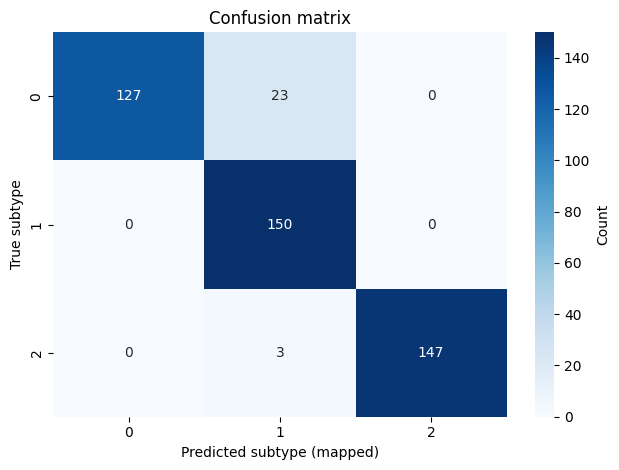

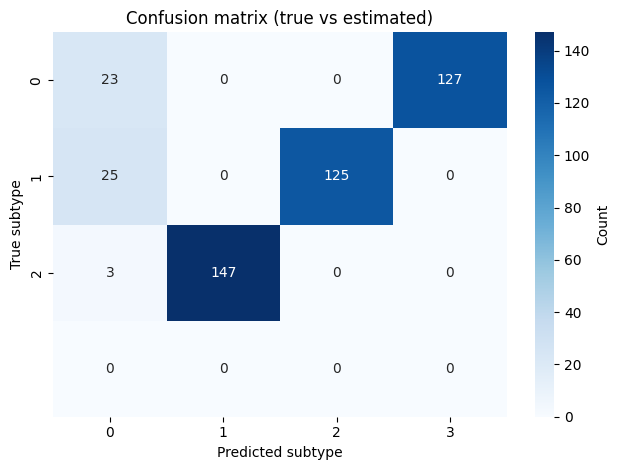


Adjusted Rand Index: 0.8371


In [31]:
import seaborn as sns

# Compute subtype mapping
best_model.compute_subtype_mapping(f_list, verbose=True)
subtype_mapping = best_model.subtype_mapping

# Print parameter comparison
print_parameter_comparison(
    fitted_f_list=best_model.cluster_f,
    fitted_scalar_K=best_model.final_scalar_K,
    fitted_s=best_model.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),
    subtype_mapping=best_model.subtype_mapping,
    n_subtypes=n_subtypes,
)

# Confusion matrix
assignments_true = np.array([p["subtype_true"] for p in X])
mapped_assignments = subtype_mapping[best_model.final_assignments]
cm_best = confusion_matrix(assignments_true, mapped_assignments)

fig, ax = plt.subplots()
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2],
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted subtype (mapped)")
ax.set_ylabel("True subtype")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

# Raw confusion matrix: rows = true subtypes, cols = estimated subtypes (may differ in count)
cm_raw = confusion_matrix(assignments_true, best_model.final_assignments)
unique_true = np.unique(assignments_true)
unique_pred = np.unique(best_model.final_assignments)
fig, ax = plt.subplots()
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=unique_pred, yticklabels=unique_true,
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted subtype")
ax.set_ylabel("True subtype")
ax.set_title("Confusion matrix (true vs estimated)")
plt.tight_layout()
plt.show()

# Adjusted Rand Index
ari = adjusted_rand_score(assignments_true, mapped_assignments)
print(f"\nAdjusted Rand Index: {ari:.4f}")


In [20]:
if getattr(best_model, 'assignment_probabilities_', None) is not None:
    import matplotlib.pyplot as plt
    probs = best_model.assignment_probabilities_
    eps = 1e-12
    entropy_per_patient = -np.sum(probs * np.log(probs + eps), axis=1)
    mean_posterior_entropy = np.mean(entropy_per_patient)
    print(f"Mean posterior entropy: {mean_posterior_entropy:.4f}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(np.max(probs, axis=1), bins=20)
    axes[0].set_xlabel('assignment probability (confidence)')
    axes[0].set_ylabel('count')
    axes[0].set_title('max assignment probability per patient')
    axes[1].hist(entropy_per_patient, bins=20)
    axes[1].set_xlabel('posterior entropy')
    axes[1].set_ylabel('ocunt')
    axes[1].set_title('posterior entropy per patient')
    plt.tight_layout()
    plt.show()

## Visualizations


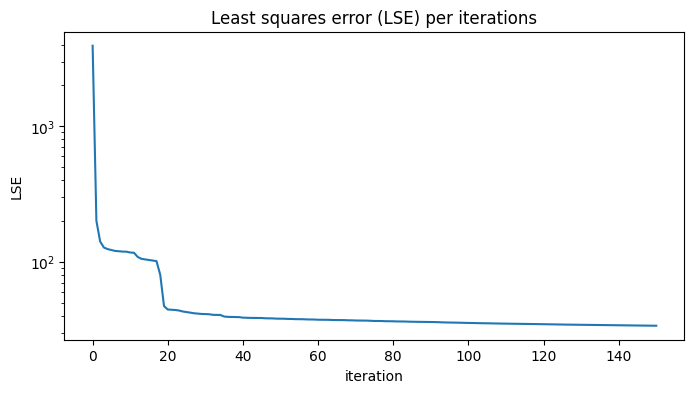

In [33]:
# Plot LSE history
plot_lse(best_model.lse_history)


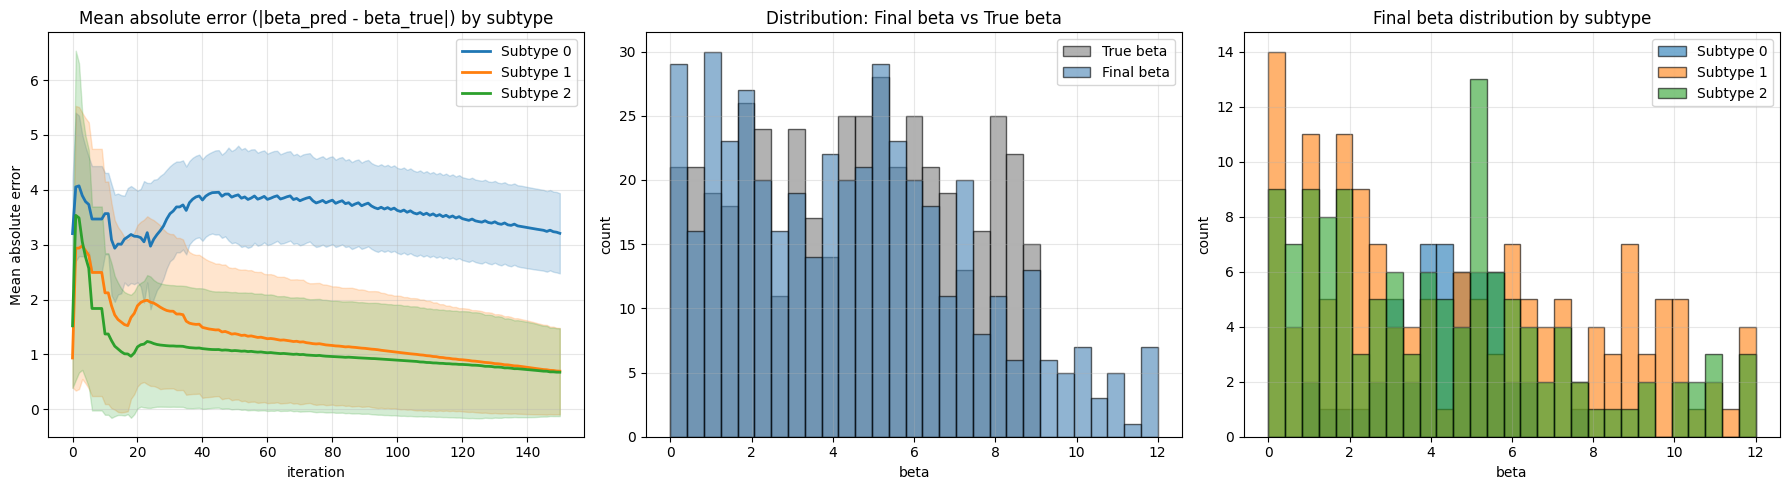

In [34]:
# Plot beta history by subtype
plot_beta_history_by_subtype(
    beta_history=best_model.beta_history,
    assignments=best_model.final_assignments,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=subtype_mapping,
)


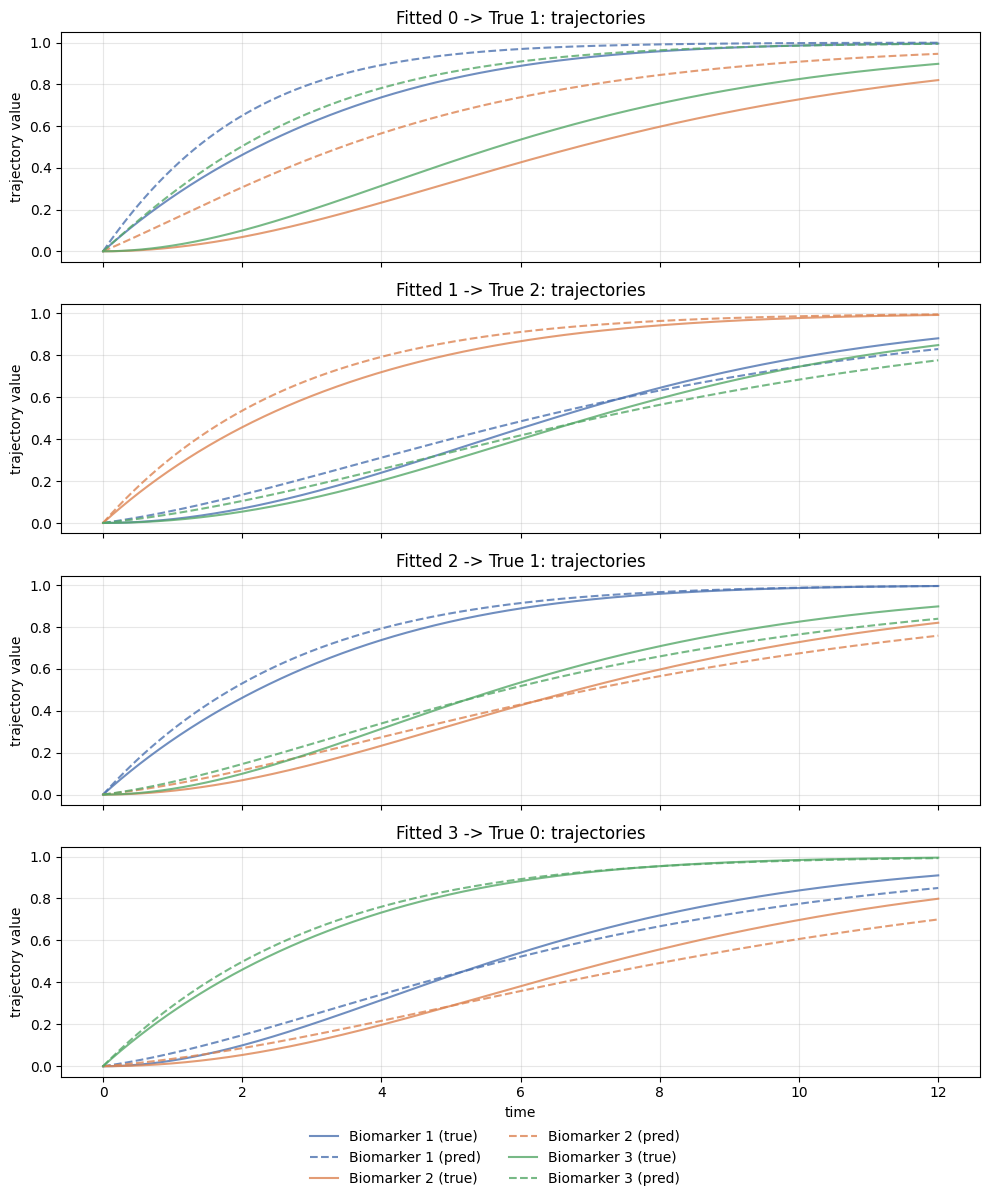

In [36]:
# Plot true vs predicted subtype trajectories
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=best_model.cluster_f,
    scalar_K_pred_list=[best_model.final_scalar_K] * len(best_model.cluster_f),
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=subtype_mapping,
)


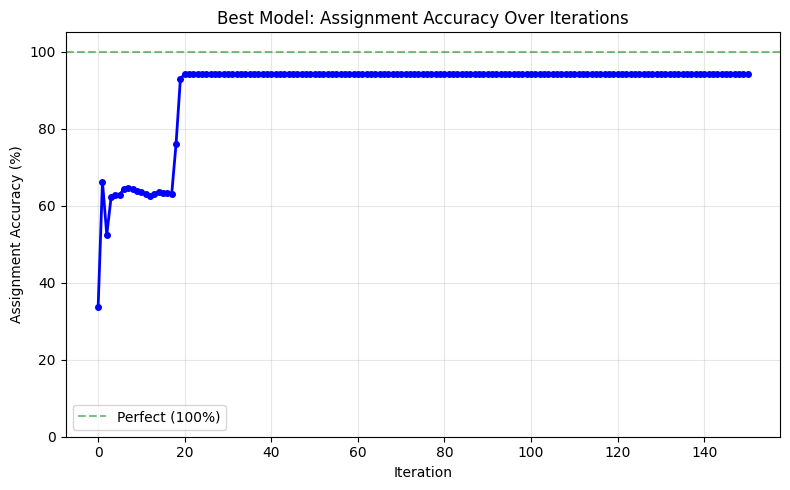

In [29]:
# Plot assignment accuracy over iterations
plot_assignment_accuracy_history(
    assignment_history=best_model.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=subtype_mapping,
    title="Best Model: Assignment Accuracy Over Iterations",
)

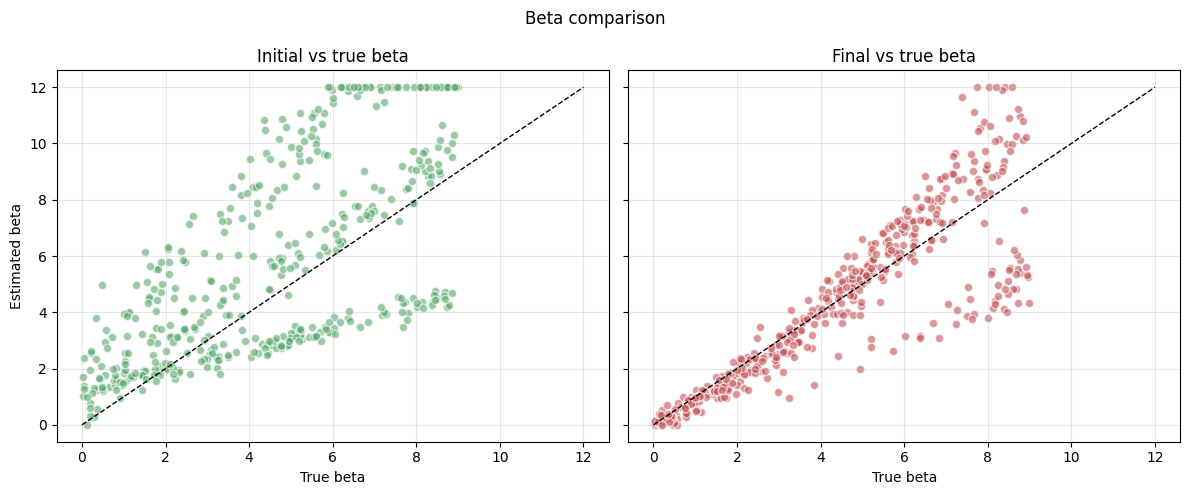

In [24]:
# Plot beta comparison
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X])
if np.any(np.isnan(beta_init_array)):
    beta_init_array = initial_beta

beta_final_array = best_model.beta_history[:, -1]
plot_beta_comparison(beta_true_array, beta_init_array, beta_final_array)
